# A3.2 – Tutorial de Clustering
**SC3314 – Inteligencia Artificial | Universidad de Monterrey**

---

En este tutorial aprenderemos a aplicar dos métodos clásicos de **aprendizaje no supervisado**: **K-Means** y **Clustering Jerárquico**. A diferencia del aprendizaje supervisado, aquí no contamos con etiquetas previas; el objetivo es descubrir estructuras ocultas en los datos agrupando observaciones similares.

El tutorial está organizado en dos grandes partes:

1. **K-Means Clustering** – trabajado sobre un dataset sintético y después sobre el dataset real NCI60.
2. **Hierarchical Clustering** – aplicado sobre el dataset NCI60 con distintas métricas y métodos de enlace.

Cada sección explica **qué se va a hacer**, **por qué se hace** y **qué significan los resultados**.

---
## Parte 1 – K-Means Clustering

### ¿Qué es K-Means?

K-Means es uno de los algoritmos de clustering más populares. Su objetivo es particionar un conjunto de datos en **K grupos (clusters)** de modo que los puntos dentro de cada grupo sean lo más similares posible entre sí y lo más diferentes posible respecto a los demás grupos.

El algoritmo funciona de forma iterativa siguiendo estos pasos:

1. **Inicialización**: Se eligen K puntos como centroides iniciales (aleatoriamente o con K-Means++).
2. **Asignación**: Cada punto se asigna al centroide más cercano (distancia euclidiana).
3. **Actualización**: Se recalcula cada centroide como la media de los puntos asignados a él.
4. **Convergencia**: Se repiten los pasos 2 y 3 hasta que los centroides no cambian significativamente.

---

### 1.1 Generación del Dataset Sintético

Comenzamos creando un dataset artificial con `make_blobs` de `sklearn`. Esto nos permite ver paso a paso cómo funciona K-Means antes de aplicarlo a datos reales.

Generamos **1000 muestras** con **3 centros** y **2 características**, lo que facilita la visualización en 2D.

In [88]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import pandas as pd

# Generamos el dataset sintético con 1000 muestras, 3 centros y 2 features
X, y = make_blobs(n_samples=1000, centers=3, n_features=2, cluster_std=2)

# Creamos un DataFrame para facilitar la manipulación de los datos
df = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])

print("Primeras 5 filas del dataset generado:")
display(df.head())
print(f"\nDimensiones del dataset: {df.shape[0]} muestras, {df.shape[1]} características")

Primeras 5 filas del dataset generado:


,Feature 1,Feature 2
0,6.565320,7.228682
1,3.136816,2.303782
2,8.357315,-0.277167
3,5.703857,7.172270
4,2.719205,7.012481



Dimensiones del dataset: 1000 muestras, 2 características


### 1.2 Visualización Inicial (Sin Etiquetas)

Antes de aplicar cualquier algoritmo, visualizamos los datos **sin etiquetas**. Esto simula la situación real del aprendizaje no supervisado: tenemos los puntos pero no sabemos a qué grupo pertenecen.

Observa que visualmente se pueden intuir agrupaciones, pero el algoritmo debe descubrirlas por sí solo.

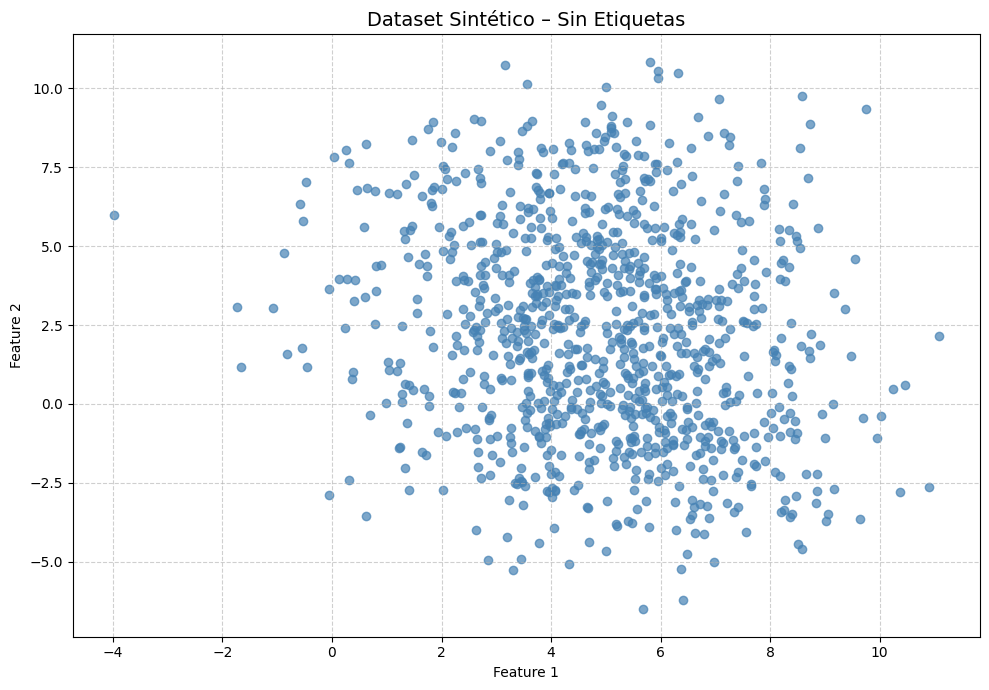

In [89]:
plt.figure(figsize=(10, 7))
plt.scatter(df['Feature 1'], df['Feature 2'], alpha=0.7, color='steelblue')
plt.title('Dataset Sintético – Sin Etiquetas', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 1.3 Paso 1 de K-Means: Asignación Aleatoria Inicial

K-Means comienza asignando **etiquetas de cluster al azar** a cada punto. Esta asignación no es correcta, pero sirve como punto de partida para calcular los primeros centroides.

Este paso ilustra por qué la inicialización es importante: una asignación inicial muy mala puede llevar a una convergencia lenta o a un mínimo local subóptimo.

In [90]:
import numpy as np

num_samples = len(df)

# Asignamos etiquetas aleatorias de cluster (0, 1 o 2) a cada punto
random_labels = np.random.randint(0, 3, num_samples)
df['Random_Cluster_Label'] = random_labels

print("Primeras 5 filas del dataset con etiquetas aleatorias:")
display(df.head())

Primeras 5 filas del dataset con etiquetas aleatorias:


,Feature 1,Feature 2,Random_Cluster_Label
0,6.565320,7.228682,0
1,3.136816,2.303782,0
2,8.357315,-0.277167,2
3,5.703857,7.172270,0
4,2.719205,7.012481,1


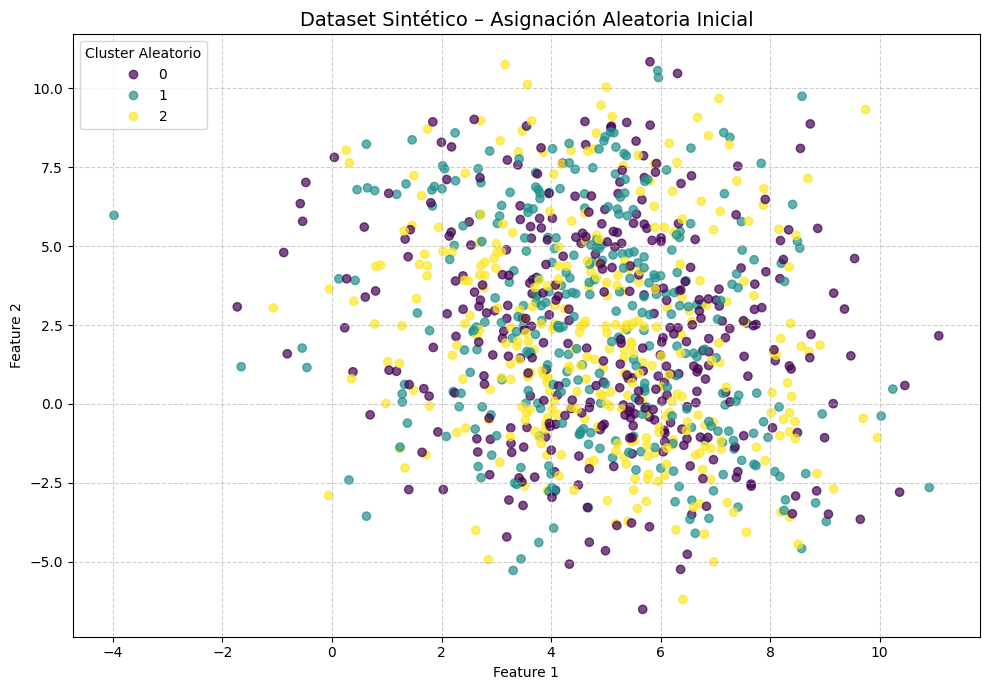

In [91]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Feature 1'], df['Feature 2'],
                      c=df['Random_Cluster_Label'], cmap='viridis', alpha=0.7)
plt.title('Dataset Sintético – Asignación Aleatoria Inicial', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(*scatter.legend_elements(), title='Cluster Aleatorio')
plt.tight_layout()
plt.show()

Como era de esperarse, la asignación aleatoria **no refleja la estructura real** del dataset. Los colores están mezclados sin ningún patrón coherente.

---

### 1.4 Paso 2 de K-Means: Cálculo de Centroides Iniciales

Una vez asignadas las etiquetas, calculamos el **centroide de cada cluster** como la media de las coordenadas de todos los puntos que le fueron asignados.

Estos centroides serán el punto de partida para la siguiente iteración de reasignación.

In [92]:
# Calculamos el centroide de cada cluster como la media de sus puntos
centroids = df.groupby('Random_Cluster_Label')[['Feature 1', 'Feature 2']].mean()

print("Centroides calculados para cada cluster aleatorio:")
display(centroids)

Centroides calculados para cada cluster aleatorio:


,Feature 1,Feature 2
Random_Cluster_Label,,
0,4.987516,2.232317
1,4.815675,2.572015
2,4.896366,2.022107


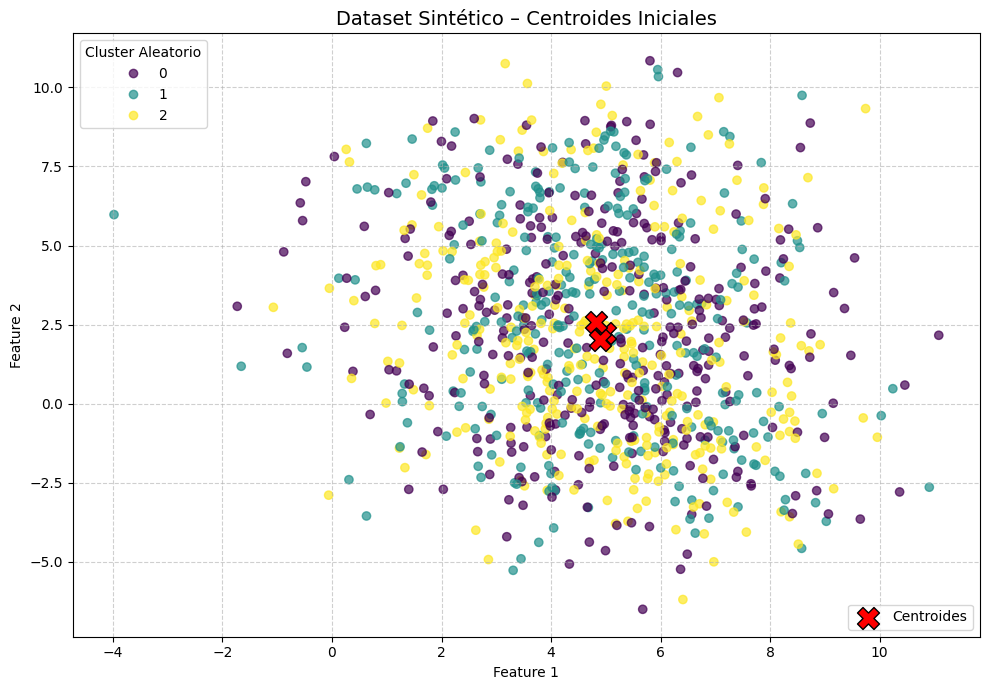

In [93]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Feature 1'], df['Feature 2'],
                      c=df['Random_Cluster_Label'], cmap='viridis', alpha=0.7)
plt.scatter(centroids['Feature 1'], centroids['Feature 2'],
            marker='X', s=250, c='red', edgecolor='black', label='Centroides', zorder=5)
plt.title('Dataset Sintético – Centroides Iniciales', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
legend1 = plt.legend(*scatter.legend_elements(), title='Cluster Aleatorio', loc='upper left')
plt.gca().add_artist(legend1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Los centroides (marcados con X roja) representan el "centro de masa" de cada grupo. Dado que la asignación fue aleatoria, los centroides están mal posicionados. La siguiente iteración los moverá hacia donde realmente están los grupos.

---

### 1.5 Paso 3: Reasignación de Puntos al Centroide Más Cercano

Ahora reasignamos cada punto al cluster cuyo centroide esté **más cerca** usando distancia euclidiana. Esta es la operación fundamental que hace que K-Means converja.

La distancia euclidiana entre un punto $p$ y un centroide $c$ se calcula como:

$$d(p, c) = \sqrt{(p_1 - c_1)^2 + (p_2 - c_2)^2}$$

In [94]:
from scipy.spatial.distance import cdist

# Obtenemos las coordenadas actuales de los centroides y de los datos
current_centroids = centroids[['Feature 1', 'Feature 2']].values
features = df[['Feature 1', 'Feature 2']].values

# Calculamos la distancia euclidiana de cada punto a cada centroide
distances = cdist(features, current_centroids, 'euclidean')

# Asignamos cada punto al centroide más cercano
new_cluster_assignments = np.argmin(distances, axis=1)
df['Random_Cluster_Label'] = new_cluster_assignments

print("Primeras 5 filas del dataset con las etiquetas de cluster actualizadas:")
display(df.head())

Primeras 5 filas del dataset con las etiquetas de cluster actualizadas:


,Feature 1,Feature 2,Random_Cluster_Label
0,6.565320,7.228682,1
1,3.136816,2.303782,1
2,8.357315,-0.277167,2
3,5.703857,7.172270,1
4,2.719205,7.012481,1


### 1.6 Paso 4: Recalcular Centroides con las Nuevas Asignaciones

Después de reasignar los puntos, recalculamos los centroides. Este proceso se repite hasta que los centroides ya no cambien (convergencia).

In [95]:
# Recalculamos los centroides basándonos en las nuevas asignaciones
centroids = df.groupby('Random_Cluster_Label')[['Feature 1', 'Feature 2']].mean()

print("Nuevos centroides calculados tras la primera iteración:")
display(centroids)

Nuevos centroides calculados tras la primera iteración:


,Feature 1,Feature 2
Random_Cluster_Label,,
0,7.121792,2.340744
1,4.255858,5.307062
2,5.105881,-0.801453


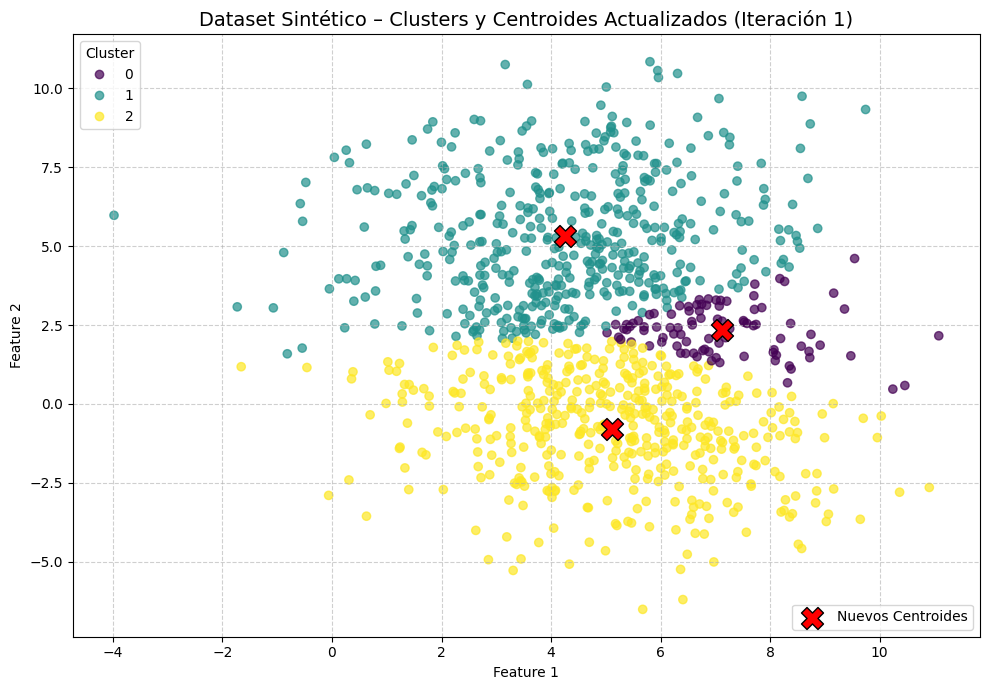

In [96]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Feature 1'], df['Feature 2'],
                      c=df['Random_Cluster_Label'], cmap='viridis', alpha=0.7)
plt.scatter(centroids['Feature 1'], centroids['Feature 2'],
            marker='X', s=250, c='red', edgecolor='black', label='Nuevos Centroides', zorder=5)
plt.title('Dataset Sintético – Clusters y Centroides Actualizados (Iteración 1)', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
legend1 = plt.legend(*scatter.legend_elements(), title='Cluster', loc='upper left')
plt.gca().add_artist(legend1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Después de solo **una iteración**, los clusters ya empiezan a parecerse a la estructura real del dataset. Los centroides se desplazaron hacia los verdaderos grupos. En la práctica, `sklearn` repite este proceso automáticamente hasta converger.

---

## Parte 1B – K-Means sobre el Dataset Real NCI60

### ¿Qué es el Dataset NCI60?

El **NCI60** es un conjunto de datos genómico del Instituto Nacional del Cáncer de EE.UU. Contiene mediciones de expresión génica de **64 líneas celulares de cáncer**, provenientes de **14 tipos diferentes de tejidos cancerosos** (pulmón, mama, colon, etc.).

- **Dimensiones**: 64 muestras × 6,830 genes (características)
- **Objetivo**: Ver si K-Means puede agrupar líneas celulares por tipo de cáncer sin conocer las etiquetas reales

Este dataset es un clásico benchmark en bioinformática y demuestra cómo el clustering puede ayudar a descubrir subtipos de enfermedades.

### 1.7 Carga del Dataset NCI60

In [97]:
# !pip install ISLP  # Descomentar si no está instalada

import ISLP
from ISLP import load_data

# Cargamos el dataset NCI60 (diccionario con 'data' y 'labels')
NCI60_dict = load_data('NCI60')
NCI60_df = pd.DataFrame(NCI60_dict['data'])

print("Información del dataset NCI60 (primeras 5 filas):")
display(NCI60_df.head())
print(f"\nDimensiones de los datos: {NCI60_df.shape[0]} muestras, {NCI60_df.shape[1]} genes")

print("\nPrimeras etiquetas (tipo de cáncer):")
display(NCI60_dict['labels'].head(10))

Información del dataset NCI60 (primeras 5 filas):


,0,1,2,3,4,5,6,7,8,9,...,6820,6821,6822,6823,6824,6825,6826,6827,6828,6829
0,0.300000,1.180000,0.550000,1.140000,-0.265000,-7.000000e-02,0.350000,-0.315000,-0.450000,-0.654980,...,-0.990020,0.000000,0.030000,-0.175000,0.629981,-0.030000,0.000000,0.280000,-0.340000,-1.930000
1,0.679961,1.289961,0.169961,0.379961,0.464961,5.799610e-01,0.699961,0.724961,-0.040039,-0.285019,...,-0.270058,-0.300039,-0.250039,-0.535039,0.109941,-0.860039,-1.250049,-0.770039,-0.390039,-2.000039
2,0.940000,-0.040000,-0.170000,-0.040000,-0.605000,0.000000e+00,0.090000,0.645000,0.430000,0.475019,...,0.319981,0.120000,-0.740000,-0.595000,-0.270020,-0.150000,0.000000,-0.120000,-0.410000,0.000000
3,0.280000,-0.310000,0.680000,-0.810000,0.625000,-1.387779e-17,0.170000,0.245000,0.020000,0.095019,...,-1.240020,-0.110000,-0.160000,0.095000,-0.350019,-0.300000,-1.150010,1.090000,-0.260000,-1.100000
4,0.485000,-0.465000,0.395000,0.905000,0.200000,-5.000000e-03,0.085000,0.110000,0.235000,1.490019,...,0.554980,-0.775000,-0.515000,-0.320000,0.634980,0.605000,0.000000,0.745000,0.425000,0.145000



Dimensiones de los datos: 64 muestras, 6830 genes

Primeras etiquetas (tipo de cáncer):


,label
0,CNS
1,CNS
2,CNS
3,RENAL
4,BREAST
5,CNS
6,CNS
7,BREAST
8,NSCLC
9,NSCLC


### 1.8 Aplicación de K-Means al NCI60

Con 6,830 dimensiones es imposible visualizar los datos directamente. Aplicamos K-Means y después usaremos **PCA** (Análisis de Componentes Principales) para reducir la dimensionalidad y poder graficar.

Usamos **K=3 clusters** y **n_init=20** (el algoritmo se corre 20 veces con distintas inicializaciones y se elige el mejor resultado) para evitar quedar atrapados en mínimos locales.

In [98]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Aplicamos K-Means con 3 clusters y 20 inicializaciones para mayor robustez
kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
kmeans.fit(NCI60_df)

# Obtenemos las etiquetas de cluster asignadas a cada línea celular
cluster_labels = kmeans.labels_

NCI60_df_clustered = NCI60_df.copy()
NCI60_df_clustered['Cluster'] = cluster_labels

print("Distribución de muestras por cluster:")
print(NCI60_df_clustered['Cluster'].value_counts().sort_index())

print("\nPrimeras 5 filas con su cluster asignado:")
display(NCI60_df_clustered[['Cluster']].head())

Distribución de muestras por cluster:
Cluster
0    35
1    20
2     9
Name: count, dtype: int64

Primeras 5 filas con su cluster asignado:


,Cluster
0,0
1,0
2,0
3,0
4,0


### 1.9 Reducción de Dimensionalidad con PCA

El **PCA (Principal Component Analysis)** proyecta los datos de alta dimensión a un espacio de menor dimensión conservando la mayor cantidad de varianza posible.

Las **componentes principales** son combinaciones lineales de las variables originales, ordenadas de mayor a menor varianza explicada. Esto nos permite visualizar en 2D o 3D datos que originalmente tienen miles de dimensiones.

In [99]:
# Aplicamos PCA para reducir de 6830 dimensiones a 5 componentes principales
pca = PCA(n_components=5)
NCI60_pca = pca.fit_transform(NCI60_df)

# Creamos un DataFrame con las componentes principales y las etiquetas de K-Means
pca_df = pd.DataFrame(
    data=NCI60_pca,
    columns=[f'PC{i+1}' for i in range(NCI60_pca.shape[1])]
)
pca_df['Cluster'] = cluster_labels

print("Primeras 5 filas del dataset en espacio PCA con etiquetas de cluster:")
display(pca_df.head())

Primeras 5 filas del dataset en espacio PCA con etiquetas de cluster:


,PC1,PC2,PC3,PC4,PC5,Cluster
0,19.795783,0.115225,-5.969119,-4.754025,4.916369,0
1,21.546101,-1.457396,-9.019777,-6.769319,2.279671,0
2,25.056621,1.526084,-6.959639,-2.788823,10.816807,0
3,37.409535,-11.389445,-5.406938,-15.444883,15.986791,0
4,50.218641,-1.346139,-17.599920,-15.093468,13.847905,0


### 1.10 Visualización de los Clusters de K-Means en el Espacio PCA

Visualizamos los clusters en distintas combinaciones de componentes principales para entender cómo se separan las líneas celulares.

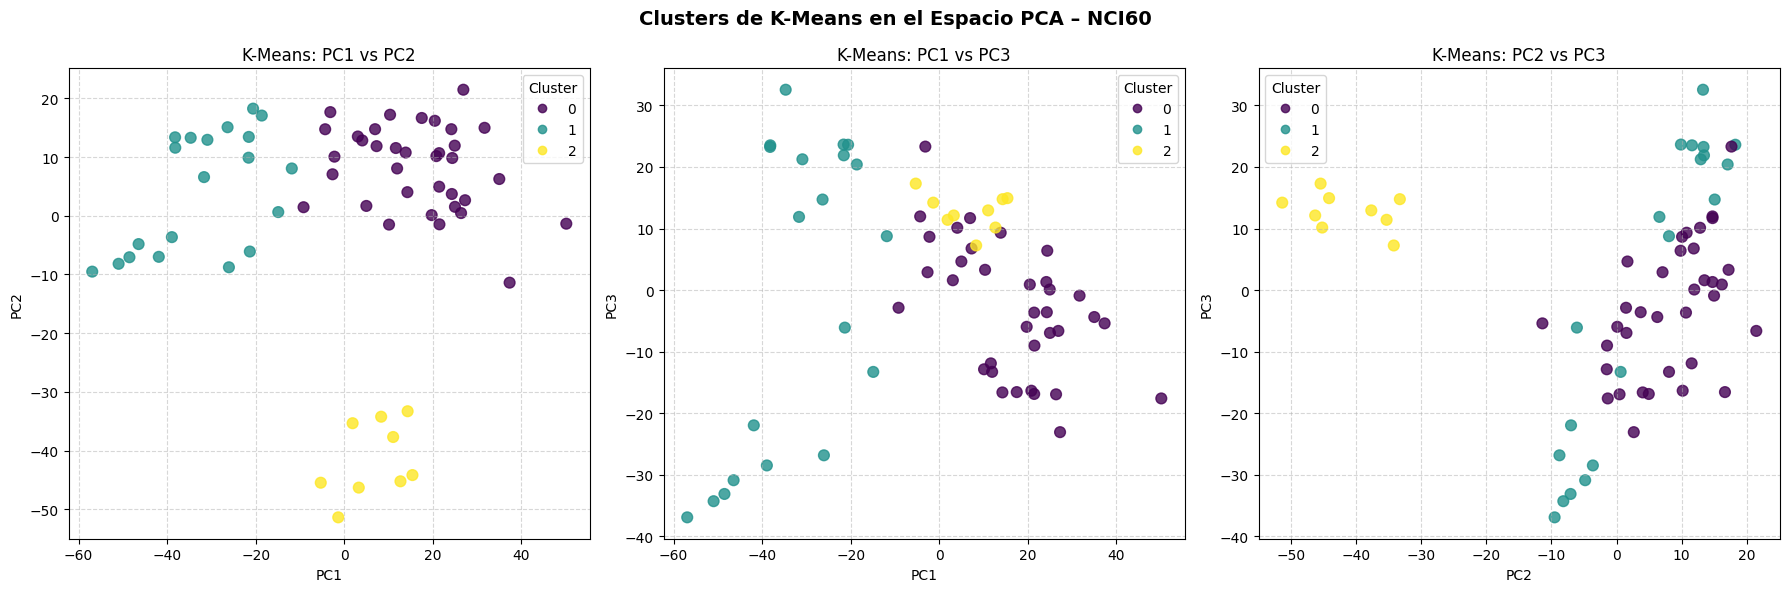

In [100]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

combinations = [('PC1', 'PC2'), ('PC1', 'PC3'), ('PC2', 'PC3')]
for ax, (pcx, pcy) in zip(axes, combinations):
    scatter = ax.scatter(pca_df[pcx], pca_df[pcy],
                         c=pca_df['Cluster'], cmap='viridis', alpha=0.8, s=60)
    ax.set_title(f'K-Means: {pcx} vs {pcy}', fontsize=12)
    ax.set_xlabel(pcx)
    ax.set_ylabel(pcy)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(*scatter.legend_elements(), title='Cluster')

plt.suptitle('Clusters de K-Means en el Espacio PCA – NCI60', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación:** Cada punto representa una línea celular de cáncer. Los colores indican el cluster asignado por K-Means. Si los clusters son significativos, esperamos ver agrupaciones coherentes con los tipos de cáncer reales (lo cual verificaremos al comparar con las etiquetas originales).

---

### 1.11 Varianza Explicada por Componente Principal

Un aspecto crucial de PCA es entender **cuánta información conservamos** al reducir la dimensionalidad. La varianza explicada nos dice qué porcentaje de la información total captura cada componente.

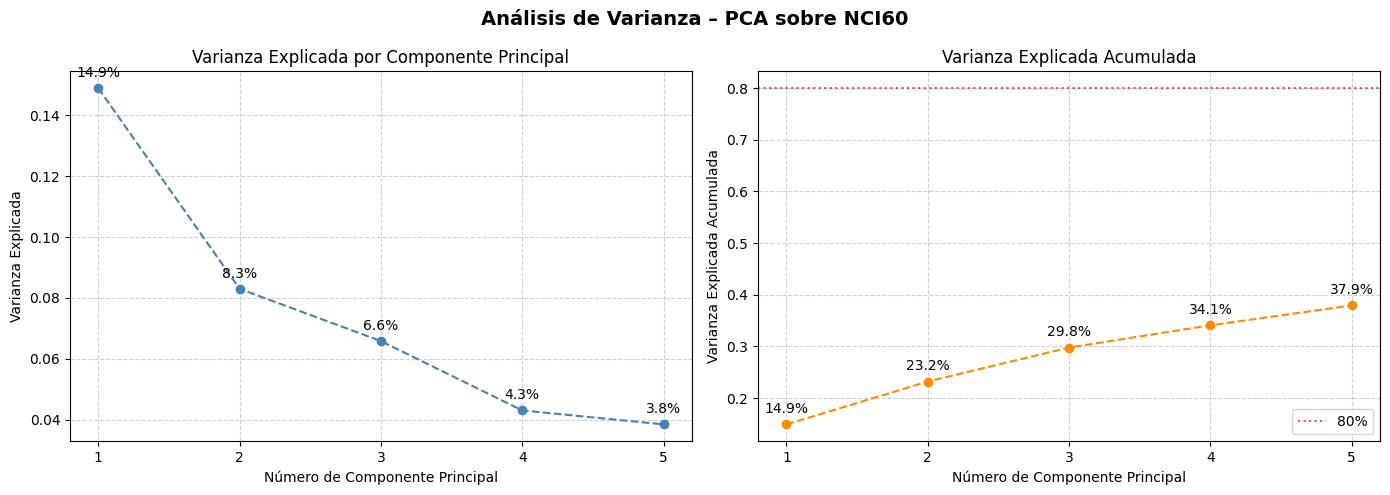

In [101]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Varianza explicada por cada componente
ax1.plot(range(1, 6), pca.explained_variance_ratio_, marker='o', linestyle='--', color='steelblue')
ax1.set_title('Varianza Explicada por Componente Principal', fontsize=12)
ax1.set_xlabel('Número de Componente Principal')
ax1.set_ylabel('Varianza Explicada')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xticks(range(1, 6))
for i, v in enumerate(pca.explained_variance_ratio_):
    ax1.annotate(f'{v:.1%}', (i+1, v), textcoords="offset points", xytext=(0, 8), ha='center')

# Varianza explicada acumulada
ax2.plot(range(1, 6), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--', color='darkorange')
ax2.axhline(y=0.8, color='red', linestyle=':', alpha=0.7, label='80%')
ax2.set_title('Varianza Explicada Acumulada', fontsize=12)
ax2.set_xlabel('Número de Componente Principal')
ax2.set_ylabel('Varianza Explicada Acumulada')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xticks(range(1, 6))
ax2.legend()
for i, v in enumerate(pca.explained_variance_ratio_.cumsum()):
    ax2.annotate(f'{v:.1%}', (i+1, v), textcoords="offset points", xytext=(0, 8), ha='center')

plt.suptitle('Análisis de Varianza – PCA sobre NCI60', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación:**
- La **PC1** captura la mayor parte de la varianza del dataset.
- Con las primeras 5 componentes capturamos un cierto porcentaje acumulado de la varianza total.
- Este análisis justifica por qué usar PCA antes de visualizar: con solo 2-3 componentes ya obtenemos una representación útil de los datos de alta dimensión.

---

## Parte 2 – Hierarchical Clustering (Clustering Jerárquico)

### ¿Qué es el Clustering Jerárquico?

A diferencia de K-Means, el **clustering jerárquico** no requiere especificar el número de clusters de antemano. En su variante **aglomerativa** (bottom-up):

1. Cada observación comienza siendo su propio cluster.
2. Se fusionan iterativamente los dos clusters más cercanos.
3. El proceso continúa hasta que todos los puntos forman un único cluster.

El resultado se visualiza como un **dendrograma**: un árbol que muestra el orden y la distancia a la que se fusionaron los clusters.

**Ventajas sobre K-Means:**
- No requiere definir K a priori.
- Revela la estructura jerárquica de los datos.
- Permite explorar diferentes números de clusters cortando el árbol en distintos niveles.

---

### 2.1 Carga y Preprocesamiento del NCI60

Antes de aplicar clustering jerárquico, **estandarizamos los datos** (media=0, desviación estándar=1). Esto es crucial cuando las variables tienen diferentes escalas, para que ninguna domine el cálculo de distancias.

In [102]:
from sklearn.preprocessing import StandardScaler

# Cargamos el dataset NCI60
nci60_dict = load_data('NCI60')
X = nci60_dict['data']
labels = nci60_dict['labels'].iloc[:, 0]

print(f"Dimensiones originales: {X.shape}")
print(f"\nTipos de cáncer presentes en el dataset:")
print(labels.value_counts())

Dimensiones originales: (64, 6830)

Tipos de cáncer presentes en el dataset:
label
RENAL          9
NSCLC          9
MELANOMA       8
BREAST         7
COLON          7
OVARIAN        6
LEUKEMIA       6
CNS            5
PROSTATE       2
UNKNOWN        1
K562B-repro    1
K562A-repro    1
MCF7A-repro    1
MCF7D-repro    1
Name: count, dtype: int64


In [103]:
# Estandarizamos los datos: media 0, desviación estándar 1
# Esto evita que genes con mayor varianza dominen el clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Media antes de escalar (primeras 3 genes): {X[:, :3].mean(axis=0).round(4)}")
print(f"Media después de escalar (primeras 3 genes): {X_scaled[:, :3].mean(axis=0).round(4)}")
print(f"\nDesv. est. después de escalar (primeras 3 genes): {X_scaled[:, :3].std(axis=0).round(4)}")

Media antes de escalar (primeras 3 genes): [-0.0191 -0.0278 -0.0199]
Media después de escalar (primeras 3 genes): [-0.  0. -0.]

Desv. est. después de escalar (primeras 3 genes): [1. 1. 1.]


### 2.2 PCA + Varianza Explicada (sobre datos estandarizados)

Aplicamos PCA sobre los datos estandarizados para visualizar la estructura del NCI60 antes de clusterizar.

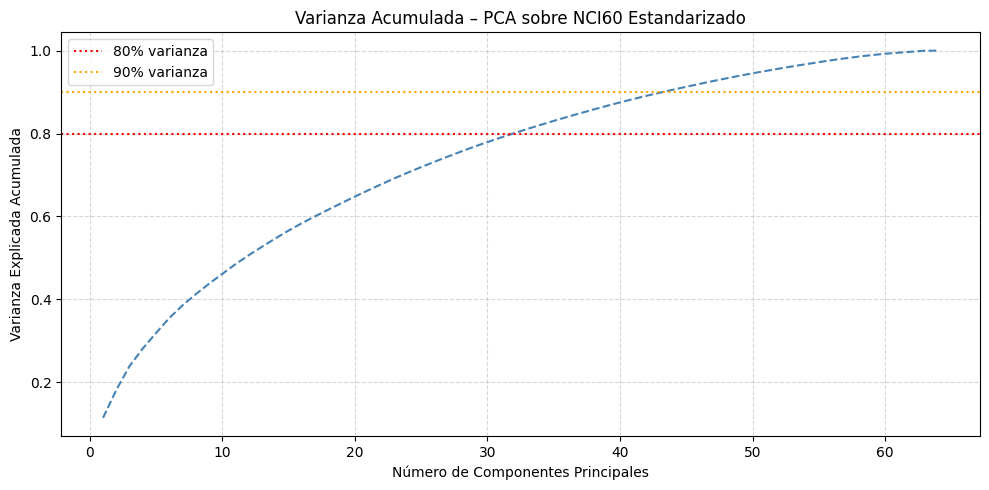

Componentes para explicar ≥80% de la varianza: 32
Componentes para explicar ≥90% de la varianza: 44


In [104]:
# Aplicamos PCA completo para analizar la varianza explicada
pca_full = PCA()
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, linestyle='--', color='steelblue')
plt.axhline(y=0.8, color='red', linestyle=':', label='80% varianza')
plt.axhline(y=0.9, color='orange', linestyle=':', label='90% varianza')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Acumulada – PCA sobre NCI60 Estandarizado')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ¿Cuántos componentes para 80% y 90%?
n80 = np.argmax(cum_var >= 0.80) + 1
n90 = np.argmax(cum_var >= 0.90) + 1
print(f"Componentes para explicar ≥80% de la varianza: {n80}")
print(f"Componentes para explicar ≥90% de la varianza: {n90}")

### 2.3 Visualización PC1 vs PC2 (coloreado por tipo de cáncer real)

Proyectamos los datos en las primeras dos componentes principales y los coloreamos con las **etiquetas reales** del NCI60. Esto nos da una referencia para evaluar si el clustering descubre agrupaciones coherentes con los tipos de cáncer.

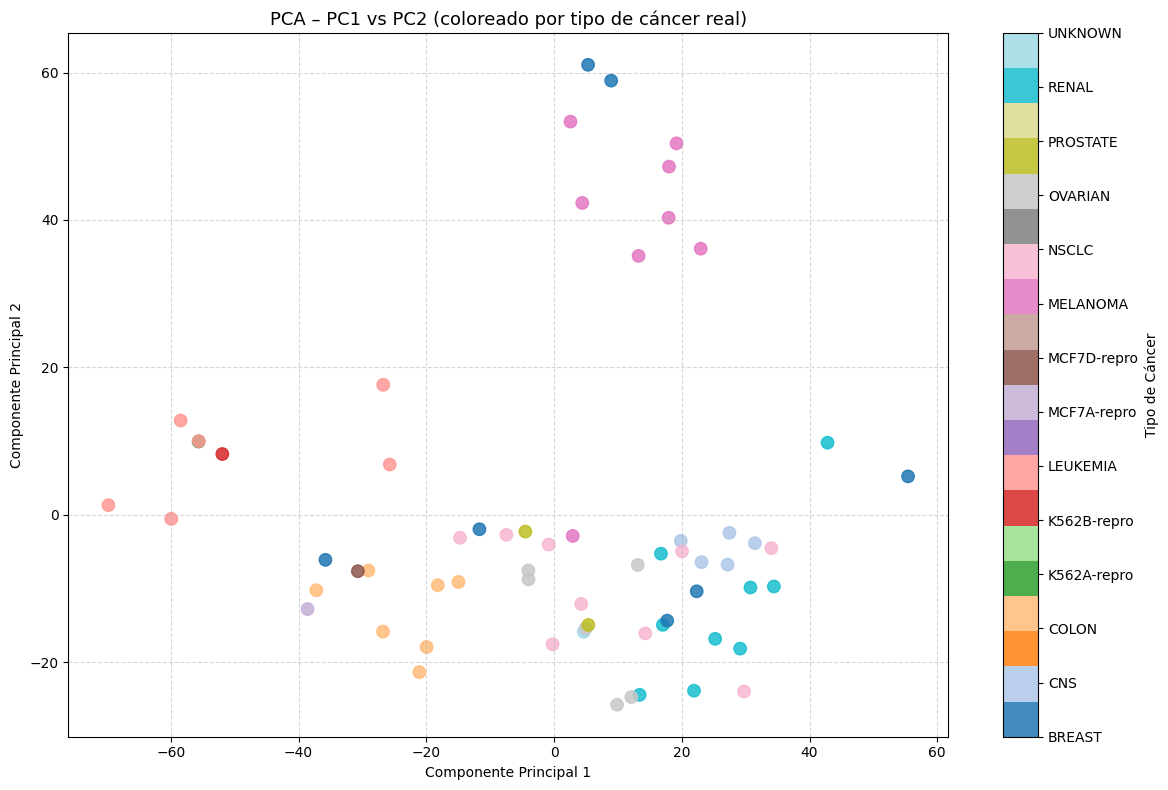

In [105]:
# Transformamos los datos a las primeras 2 componentes principales
X_pca = pca_full.fit_transform(X_scaled)

# Codificamos las etiquetas como números para colorear
label_codes = labels.astype('category').cat.codes
unique_labels = labels.unique()

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=label_codes, cmap='tab20', s=80, alpha=0.85)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA – PC1 vs PC2 (coloreado por tipo de cáncer real)', fontsize=13)
cbar = plt.colorbar(scatter, ticks=range(len(unique_labels)))
cbar.set_ticklabels(sorted(unique_labels))
cbar.set_label('Tipo de Cáncer')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretación:** Cada color representa un tipo de cáncer diferente. Si observamos que líneas del mismo tipo tienden a agruparse, esto sugiere que los datos tienen una estructura jerárquica que los algoritmos de clustering pueden descubrir.

---

### 2.4 Clustering Jerárquico – Linkage 'Complete' + Métrica 'Euclidean'

Aplicamos el clustering jerárquico con el método de enlace **complete** (también llamado enlace máximo): la distancia entre dos clusters se define como la distancia **máxima** entre cualquier par de puntos de ambos clusters.

**¿Por qué 'complete'?** Es robusto frente a outliers y tiende a producir clusters más compactos y de tamaño similar.

In [106]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Clustering jerárquico con enlace 'complete' y métrica euclidiana
hierarchical_euclidean = linkage(X_scaled, method='complete', metric='euclidean')

print(f"Matriz de linkage generada: {hierarchical_euclidean.shape}")
print("Cada fila indica: [índice_cluster1, índice_cluster2, distancia, num_elementos]")
print("\nPrimeras 3 fusiones:")
print(hierarchical_euclidean[:3])

Matriz de linkage generada: (63, 4)
Cada fila indica: [índice_cluster1, índice_cluster2, distancia, num_elementos]

Primeras 3 fusiones:
[[56.         57.         48.82671333  2.        ]
 [49.         50.         53.38504247  2.        ]
 [34.         35.         56.17719319  2.        ]]


### 2.5 Dendrograma Monocromático (Complete + Euclidean)

El **dendrograma** es la representación visual del proceso de fusión jerárquica. La **altura del eje Y** indica la distancia a la que se fusionaron dos clusters: mayor altura = clusters más diferentes entre sí.

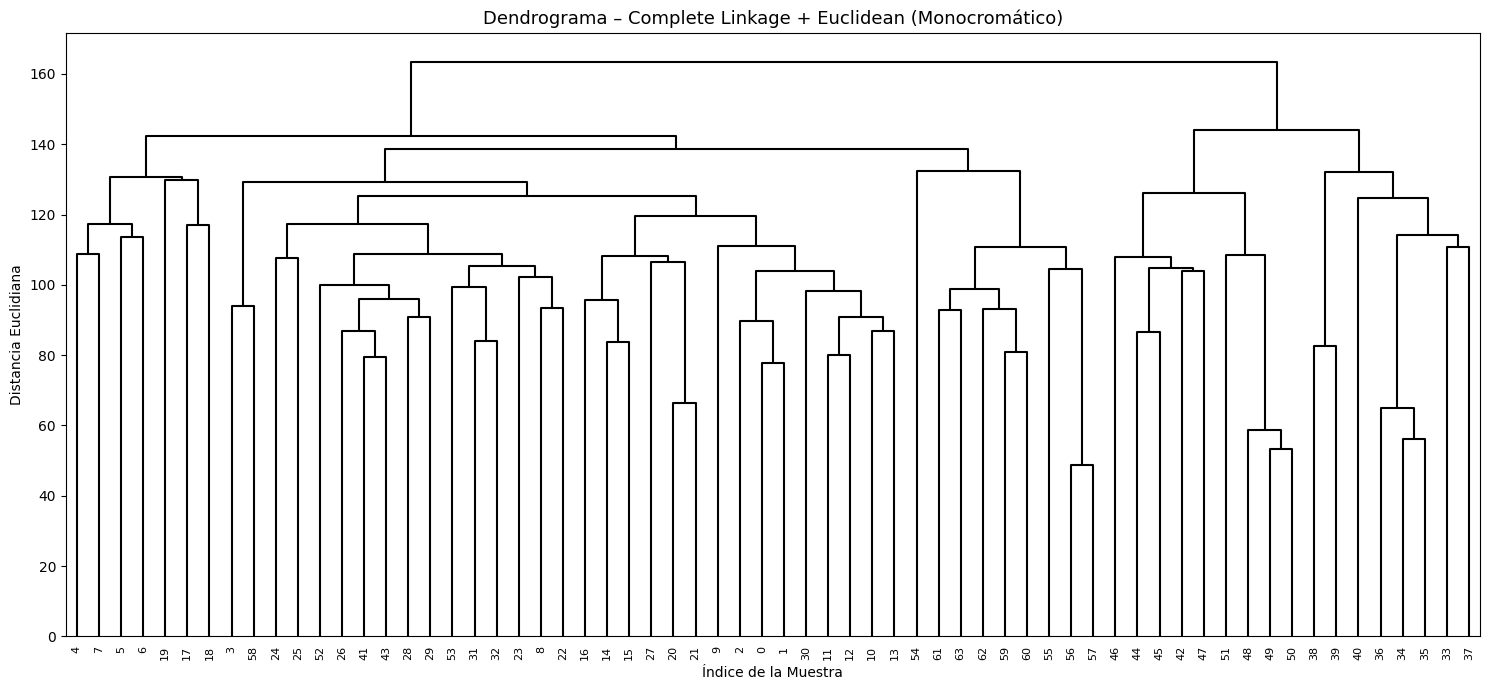

In [107]:
plt.figure(figsize=(15, 7))
dendrogram(
    hierarchical_euclidean,
    leaf_rotation=90.,
    leaf_font_size=8.,
    color_threshold=0,
    above_threshold_color='black'
)
plt.title('Dendrograma – Complete Linkage + Euclidean (Monocromático)', fontsize=13)
plt.xlabel('Índice de la Muestra')
plt.ylabel('Distancia Euclidiana')
plt.tight_layout()
plt.show()

**Interpretación del dendrograma monocromático:** Las hojas del árbol son las 64 líneas celulares. Las ramas que se unen a menor altura son muestras más similares. Las grandes fusiones en la parte superior del árbol representan grupos muy distintos entre sí. El dendrograma nos sugiere cuántos clusters naturales existen: si hay un "salto" grande en la altura de fusión, es una buena señal de que existe una separación clara entre grupos.

---

### 2.6 Dendrograma Policromático (Complete + Euclidean)

El dendrograma policromático usa colores diferentes para distinguir los clusters cuando se "corta" el árbol en el umbral por defecto de scipy. Esto facilita la identificación visual del número natural de clusters.

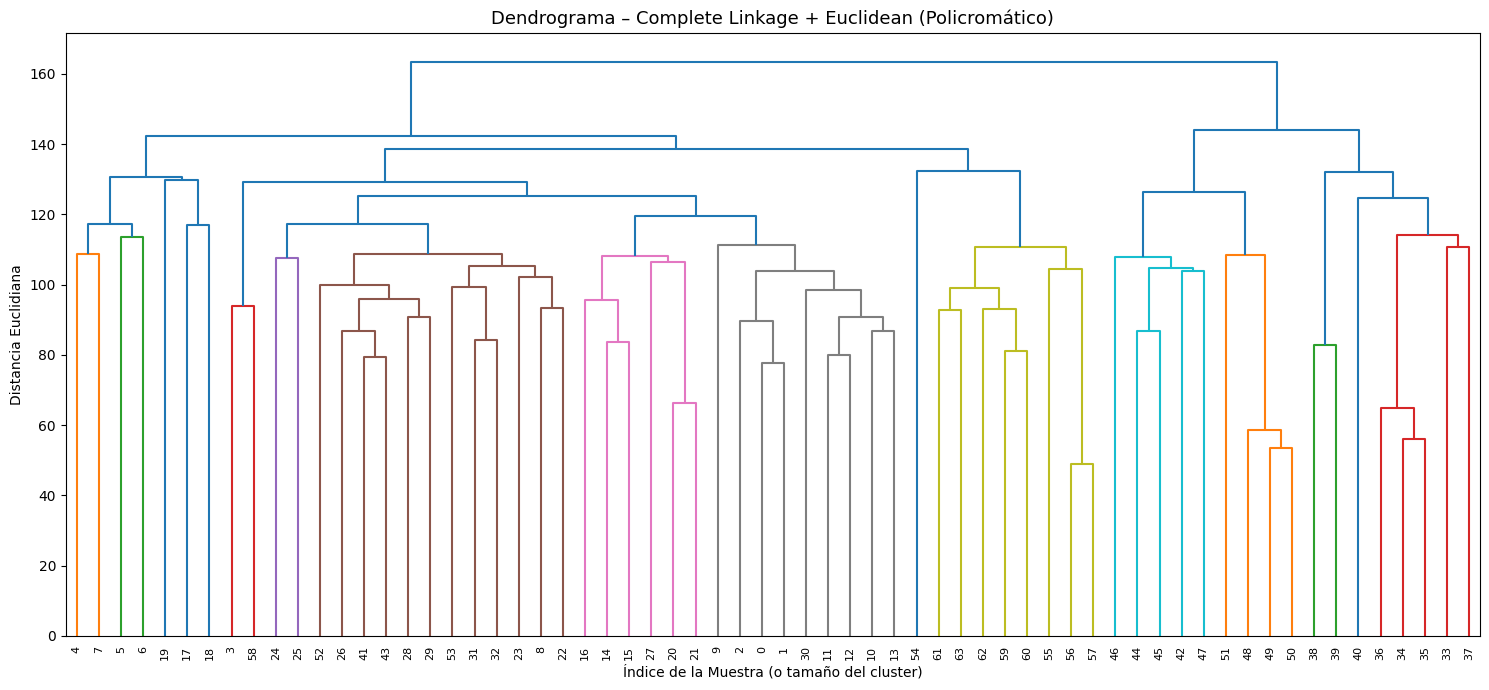

In [108]:
N_samples = X_scaled.shape[0]

plt.figure(figsize=(15, 7))
dendrogram(
    hierarchical_euclidean,
    leaf_rotation=90.,
    leaf_font_size=8.,
    show_leaf_counts=True
)
plt.title('Dendrograma – Complete Linkage + Euclidean (Policromático)', fontsize=13)
plt.xlabel('Índice de la Muestra (o tamaño del cluster)')
plt.ylabel('Distancia Euclidiana')
plt.tight_layout()
plt.show()

**Interpretación:** Los colores revelan cuántos grupos sugiere el umbral por defecto. Podemos ver que los datos tienden a organizarse en un pequeño número de grupos principales, lo cual es consistente con los 14 tipos de cáncer del dataset.

---

### 2.7 Dendrogramas con Número Específico de Clusters (2, 3 y 4)

Para determinar el número óptimo de clusters, visualizamos el dendrograma cortado en distintos niveles. La **línea roja punteada** indica el umbral de corte.

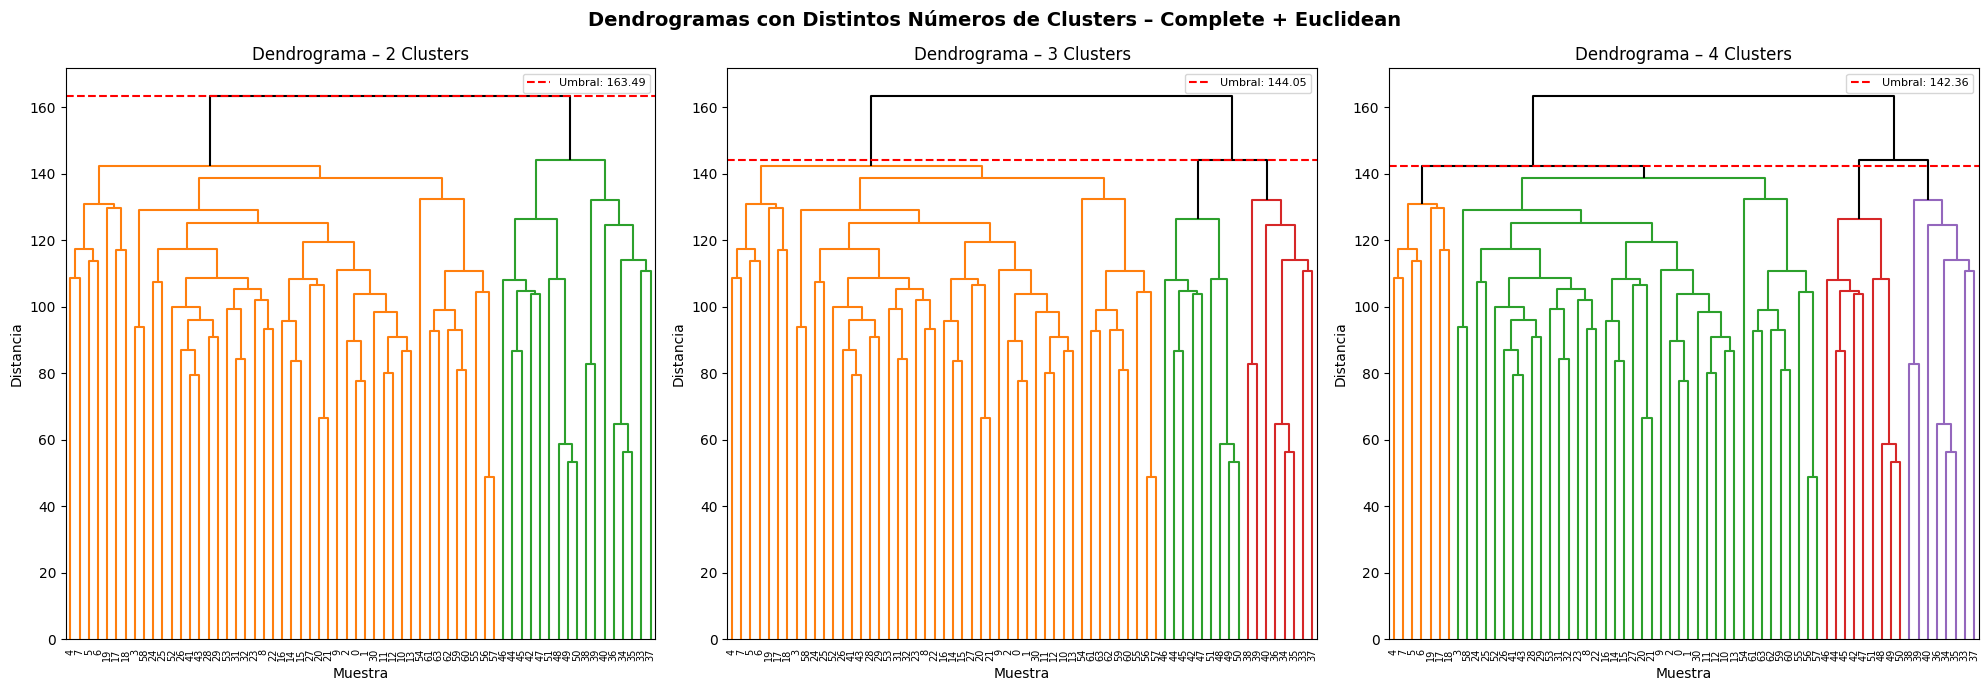

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, n_clusters in zip(axes, [2, 3, 4]):
    # El umbral para obtener n clusters se obtiene de la distancia de la fusión (N - n)-ésima
    threshold = hierarchical_euclidean[N_samples - n_clusters, 2]

    plt.sca(ax)
    dendrogram(
        hierarchical_euclidean,
        leaf_rotation=90.,
        leaf_font_size=7.,
        color_threshold=threshold,
        above_threshold_color='black',
        show_leaf_counts=True,
        ax=ax
    )
    ax.axhline(y=threshold, color='red', linestyle='--',
               label=f'Umbral: {threshold:.2f}')
    ax.set_title(f'Dendrograma – {n_clusters} Clusters', fontsize=12)
    ax.set_xlabel('Muestra')
    ax.set_ylabel('Distancia')
    ax.legend(fontsize=8)

plt.suptitle('Dendrogramas con Distintos Números de Clusters – Complete + Euclidean',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación:**
- **2 clusters**: Hay una separación muy amplia entre dos grupos principales. La distancia de corte es muy alta, lo que implica que los dos grupos son muy diferentes entre sí.
- **3 clusters**: Se refina la partición, revelando una subdivisión adicional. Corresponde aproximadamente a familias de cánceres.
- **4 clusters**: Añade otra subdivisión. El análisis del contenido biológico de cada cluster permitiría validar si esta granularidad tiene sentido.

---

### 2.8 Clustering Jerárquico con Métrica 'Correlation'

Ahora usamos la **métrica de correlación** en lugar de la euclidiana. En genómica, la correlación es frecuentemente preferida porque captura la **similitud en el patrón de expresión** independientemente de la magnitud absoluta.

Si dos genes tienen valores altos y bajos en las mismas muestras (aunque en escalas distintas), la correlación los considerará similares.

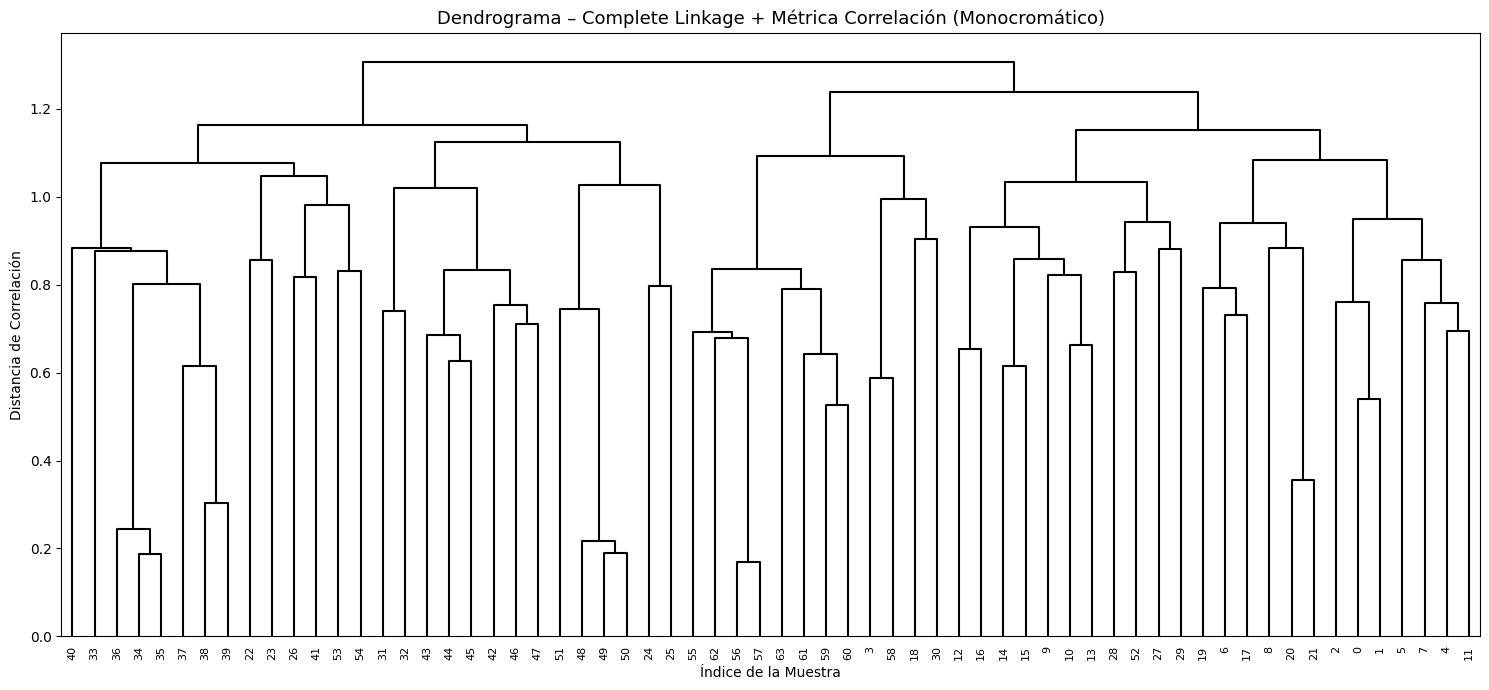

In [110]:
# Clustering con métrica de correlación y enlace 'complete'
hierarchical_correlation = linkage(X_scaled, method='complete', metric='correlation')

plt.figure(figsize=(15, 7))
dendrogram(
    hierarchical_correlation,
    leaf_rotation=90.,
    leaf_font_size=8.,
    color_threshold=0,
    above_threshold_color='black'
)
plt.title('Dendrograma – Complete Linkage + Métrica Correlación (Monocromático)', fontsize=13)
plt.xlabel('Índice de la Muestra')
plt.ylabel('Distancia de Correlación')
plt.tight_layout()
plt.show()

**Comparación con la métrica Euclidiana:**

| Aspecto | Euclidiana | Correlación |
|---|---|---|
| Mide | Distancia en el espacio de features | Similitud de patrones |
| Sensible a escala | Sí (por eso se estandariza) | No (normaliza automáticamente) |
| Uso en genómica | Menos común | Muy común |

Con la métrica de correlación, la altura del eje Y ahora va de 0 a 2 (donde 0 = perfectamente correlacionados, 2 = perfectamente anticorrelacionados). Los clusters formados pueden ser distintos, reflejando grupos con patrones similares de expresión génica.

---

### 2.9 Clustering Jerárquico con Enlace 'Average' + Métrica 'Euclidean'

Exploramos el efecto de cambiar el método de **enlace (linkage)**. El método **average** define la distancia entre dos clusters como el **promedio** de todas las distancias entre pares de puntos de ambos clusters.

Comparando con `complete` (máximo) y `single` (mínimo), el enlace `average` ofrece un término medio entre robustez y sensibilidad.

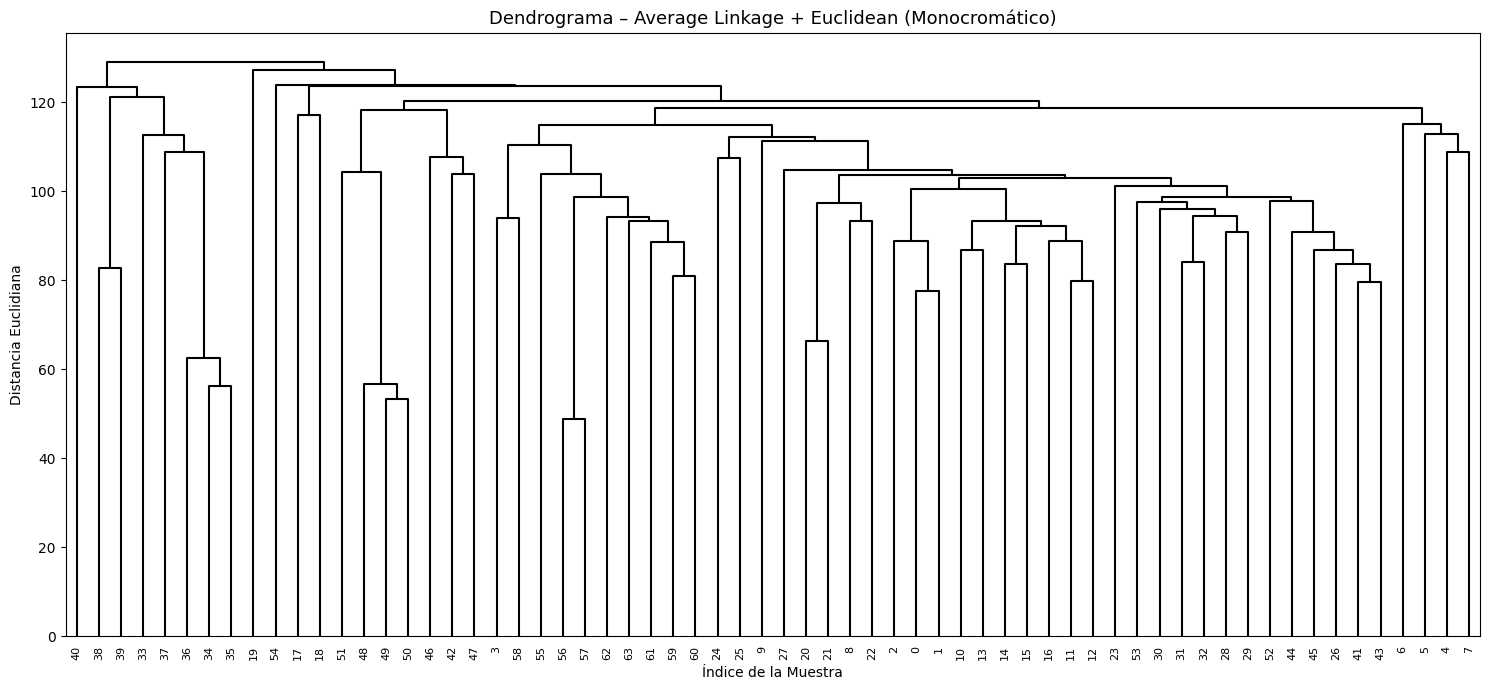

In [111]:
# Clustering con enlace 'average' y métrica euclidiana
hierarchical_average = linkage(X_scaled, method='average', metric='euclidean')

plt.figure(figsize=(15, 7))
dendrogram(
    hierarchical_average,
    leaf_rotation=90.,
    leaf_font_size=8.,
    color_threshold=0,
    above_threshold_color='black'
)
plt.title('Dendrograma – Average Linkage + Euclidean (Monocromático)', fontsize=13)
plt.xlabel('Índice de la Muestra')
plt.ylabel('Distancia Euclidiana')
plt.tight_layout()
plt.show()

---

## Parte 3 – Comparación Final y Conclusiones

### 3.1 Resumen Comparativo de Métodos

| Método | Parámetros clave | Ventajas | Desventajas |
|--------|------------------|----------|-------------|
| **K-Means** | K (número de clusters), n_init | Rápido, escalable | Requiere definir K, sensible a inicialización y outliers |
| **Jerárquico Complete** | Linkage, métrica | No requiere K, dendrograma informativo | Costoso computacionalmente O(n²) |
| **Jerárquico Average** | Linkage, métrica | Balance entre complete y single | Menos robusto a outliers que complete |

### 3.2 Conclusiones

1. **K-Means** es eficiente y funciona bien cuando los clusters son aproximadamente esféricos y de tamaño similar. En el NCI60, con K=3, encontró agrupaciones consistentes con las familias biológicas principales.

2. **El clustering jerárquico** revela la estructura multinivel de los datos sin necesidad de prefijar K. El dendrograma permite explorar visualmente cuántos clusters son naturales.

3. **La elección de la métrica importa**: La distancia euclidiana mide separación en el espacio de features, mientras que la correlación mide similitud de patrones. En genómica, la correlación suele ser más apropiada porque dos genes con expresión "alta-baja" en las mismas muestras son biológicamente similares aunque difieran en magnitud.

4. **El método de linkage importa**: `complete` produce clusters más compactos y uniformes, `average` es un término medio, y `single` tiende a crear clusters elongados (efecto de chaining).

5. **PCA como herramienta de visualización** es indispensable cuando los datos tienen muchas dimensiones. Aunque se pierde información al proyectar en pocas componentes, se gana interpretabilidad.

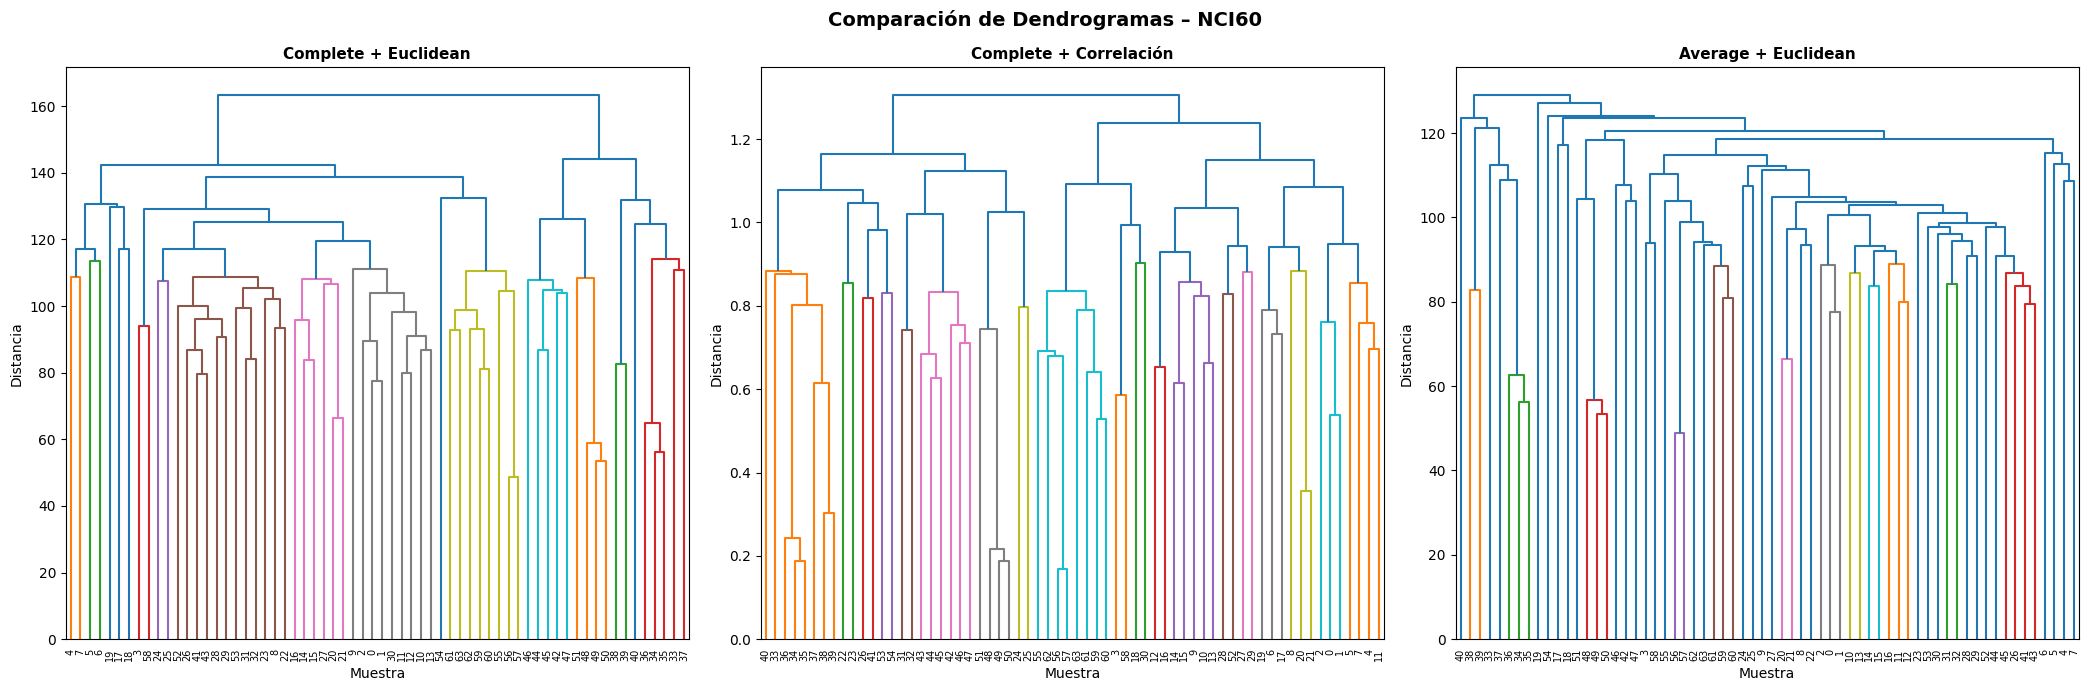

✅ Tutorial A3.2 completado exitosamente.
   Se cubrieron: K-Means paso a paso, K-Means sobre NCI60, PCA,
   Clustering Jerárquico con distintos linkages y métricas.


In [112]:
# Comparación visual de los tres dendrogramas en una sola figura
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

configs = [
    (hierarchical_euclidean, 'Complete + Euclidean'),
    (hierarchical_correlation, 'Complete + Correlación'),
    (hierarchical_average, 'Average + Euclidean'),
]

for ax, (hc, title) in zip(axes, configs):
    plt.sca(ax)
    dendrogram(
        hc,
        leaf_rotation=90.,
        leaf_font_size=7.,
        show_leaf_counts=True,
        ax=ax
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Muestra')
    ax.set_ylabel('Distancia')

plt.suptitle('Comparación de Dendrogramas – NCI60', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Tutorial A3.2 completado exitosamente.")
print("   Se cubrieron: K-Means paso a paso, K-Means sobre NCI60, PCA,")
print("   Clustering Jerárquico con distintos linkages y métricas.")